Loading: /g/data/ky13/climate-indices/bias-adjusted-indices/AUS-20i/NSW-Government/ACCESS-ESM1-5/ssp126/r6i1p1f1/NARCliM2-0-WRF412R3/v1-r1-NSWGovernment-CDF-AGCDv1-1990-2009/mon/TXge35/v20241122/TXge35_AUS-20i_ACCESS-ESM1-5_ssp126_r6i1p1f1_NSW-Government_NARCliM2-0-WRF412R3_v1-r1-NSWGovernment-CDF-AGCDv1-1990-2009_mon_201501-210012.nc

Hot Days (Tmax ≥ 35 °C)
Reference mean (masked domain): 26.07 days/season
Future mean    (masked domain): 26.99 days/season
Signal mean    (masked domain): 0.93 Δdays/season


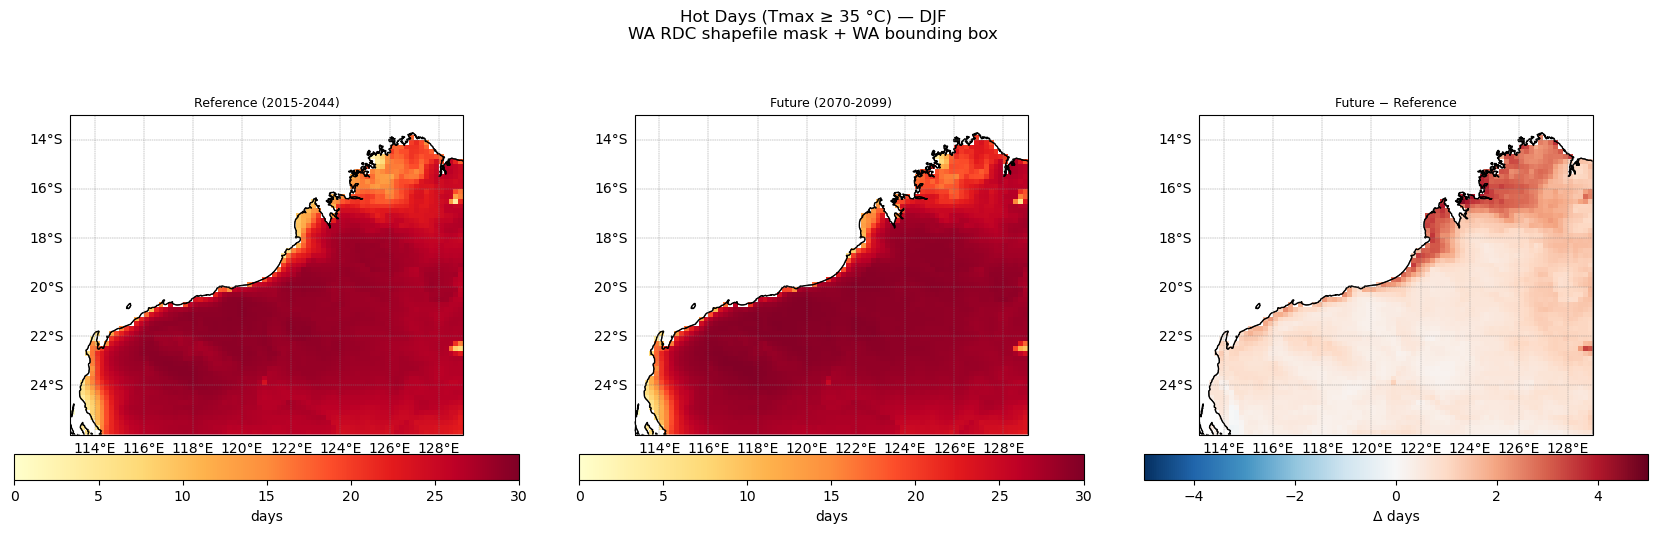

In [1]:
# ================================================================
# ANALYSIS CONFIGURATION
# ================================================================

INDEX = "TXge35"
INDEX_LABEL = {
    "TXge35": "Hot Days (Tmax ≥ 35 °C)",
    "TX90p": "Warm Days (Tmax > 90th percentile)",
    "TX10p": "Cool Days (Tmax < 10th percentile)",
    "TXgt50p": "Very Warm Days (Tmax > 50th percentile)",
}

SEASON = "DJF"  # austral summer

# ---- Local NetCDF file (replaces THREDDS) ----
DATA_FILE = (
    "/g/data/ky13/climate-indices/bias-adjusted-indices/AUS-20i/NSW-Government/"
    "ACCESS-ESM1-5/ssp126/r6i1p1f1/NARCliM2-0-WRF412R3/"
    "v1-r1-NSWGovernment-CDF-AGCDv1-1990-2009/mon/TXge35/v20241122/"
    "TXge35_AUS-20i_ACCESS-ESM1-5_ssp126_r6i1p1f1_NSW-Government_"
    "NARCliM2-0-WRF412R3_v1-r1-NSWGovernment-CDF-AGCDv1-1990-2009_mon_201501-210012.nc"
)

# ---- WA RDC shapefile ----
SHAPEFILE = (
    "/g/data/ky13/mm5847/jupyter-experiment/"
    "Regional_Development_Commissions_Regions_DPIRD_020_WA_GDA2020_Public_Shapefile/"
    "Regional_Development_Commissions_Regions_DPIRD_020.shp"
)

# ---- WA bounding box ----
LON_MIN, LON_MAX = 113, 129
LAT_MIN, LAT_MAX = -26, -13

# ---- Periods ----
REF_START, REF_END = 2015, 2044
FUT_START, FUT_END = 2070, 2099


# ================================================================
# Imports
# ================================================================

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm

import geopandas as gpd


# ================================================================
# Helper definitions
# ================================================================

SEASON_MONTHS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}


def _get_lat_lon(ds):
    """
    Return (lat, lon) DataArrays from a dataset with a few common fallbacks.
    Works whether lat/lon are 1-D or 2-D.
    """
    for lat_name in ["lat", "latitude", "LAT", "nav_lat"]:
        if lat_name in ds.variables:
            lat = ds[lat_name]
            break
    else:
        raise KeyError("Could not find latitude variable (tried lat/latitude/LAT/nav_lat).")

    for lon_name in ["lon", "longitude", "LON", "nav_lon"]:
        if lon_name in ds.variables:
            lon = ds[lon_name]
            break
    else:
        raise KeyError("Could not find longitude variable (tried lon/longitude/LON/nav_lon).")

    return lat, lon


def _lon_to_360(lon):
    """Convert lon to 0..360 convention without changing dims."""
    return (lon + 360) % 360


def build_bbox_mask(lat, lon):
    """
    Boolean mask (2-D) for cells inside bounding box.
    Works whether lat/lon are 1-D or 2-D.
    """
    lon360 = _lon_to_360(lon)

    # Ensure 2-D lat/lon grids
    # If already 2-D, broadcast returns same; if 1-D, it builds a mesh.
    lat2d, lon2d = xr.broadcast(lat, lon360)

    return (
        (lon2d >= LON_MIN) & (lon2d <= LON_MAX) &
        (lat2d >= LAT_MIN) & (lat2d <= LAT_MAX)
    )


def build_shapefile_mask(lat, lon, shapefile_path, pre_mask):
    """
    Shapefile mask using GeoPandas spatial join (Shapely 1.8 / GeoPandas 0.11 safe).
    Uses pre_mask (2-D) to limit points for speed.

    Returns: 2-D boolean DataArray aligned to pre_mask dims.
    """
    # Read polygons and ensure geographic lon/lat CRS
    gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
    geom = gdf.unary_union
    poly = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")

    lon360 = _lon_to_360(lon)

    # Ensure 2-D grids that match the mask
    lat2d, lon2d = xr.broadcast(lat, lon360)

    # Align mask to lat2d/lon2d dims (important if xarray reorders dims)
    pre_mask = pre_mask.transpose(*lat2d.dims)

    flat_mask = pre_mask.values.ravel()

    x = lon2d.values.ravel()[flat_mask]
    y = lat2d.values.ravel()[flat_mask]

    pts = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(x, y),
        crs="EPSG:4326"
    )

    # GeoPandas 0.11 uses predicate; some installs still use op
    try:
        joined = gpd.sjoin(pts, poly, how="left", predicate="within")
    except TypeError:
        joined = gpd.sjoin(pts, poly, how="left", op="within")

    inside_small = joined["index_right"].notna().to_numpy()

    inside_full = np.zeros(lat2d.size, dtype=bool)
    inside_full[flat_mask] = inside_small
    inside_full = inside_full.reshape(lat2d.shape)

    return xr.DataArray(
        inside_full,
        coords=lat2d.coords,
        dims=lat2d.dims,
        name="shape_mask"
    )


def load_season_from_file(path, season, apply_shapefile=True):
    """
    Load local NetCDF file, extract seasonal months,
    apply WA bbox + shapefile mask, assign season_year.
    Returns: DataArray of INDEX with mask applied.
    """
    ds = xr.open_dataset(path)

    if INDEX not in ds.data_vars:
        raise KeyError(f"Variable '{INDEX}' not found. Available: {list(ds.data_vars)}")

    lat, lon = _get_lat_lon(ds)
    da = ds[INDEX]

    # ---- seasonal subset ----
    months = SEASON_MONTHS[season]
    da = da.sel(time=da.time.dt.month.isin(months))

    # ---- season_year coordinate ----
    year = da.time.dt.year
    month = da.time.dt.month
    if season == "DJF":
        season_year = xr.where(month == 12, year + 1, year)
    else:
        season_year = year
    da = da.assign_coords(season_year=("time", season_year.data))

    # ---- WA bbox mask ----
    bbox_mask = build_bbox_mask(lat, lon)
    da = da.where(bbox_mask)

    # ---- WA RDC shapefile mask ----
    if apply_shapefile:
        shape_mask = build_shapefile_mask(lat, lon, SHAPEFILE, bbox_mask)
        da = da.where(shape_mask)

    return da


# ================================================================
# Run analysis
# ================================================================

print("Loading:", DATA_FILE)
index_seas = load_season_from_file(DATA_FILE, SEASON, apply_shapefile=True)

# Get plotting grids (2-D, regardless of original lat/lon dimensionality)
ds_tmp = xr.open_dataset(DATA_FILE)
lat, lon = _get_lat_lon(ds_tmp)
lat2d, lon2d = xr.broadcast(lat, _lon_to_360(lon))

# 1) seasonal annual mean (one value per season_year per cell)
seas_annual = index_seas.groupby("season_year").mean("time")

# 2) reference climatology
seas_ref = seas_annual.sel(season_year=slice(REF_START, REF_END)).mean("season_year")

# 3) future climatology
seas_fut = seas_annual.sel(season_year=slice(FUT_START, FUT_END)).mean("season_year")

# 4) change signal
seas_signal = seas_fut - seas_ref

valid = np.isfinite(seas_ref.values)

print(f"\n{INDEX_LABEL.get(INDEX, INDEX)}")
print(f"Reference mean (masked domain): {float(seas_ref.values[valid].mean()):.2f} days/season")
print(f"Future mean    (masked domain): {float(seas_fut.values[valid].mean()):.2f} days/season")
print(f"Signal mean    (masked domain): {float(seas_signal.values[valid].mean()):.2f} Δdays/season")


# ================================================================
# Plotting (3 panels)
# ================================================================

cmap_count = "YlOrRd"
cmap_signal = "RdBu_r"

vmax_count = float(np.nanmax([seas_ref.max().values, seas_fut.max().values]))
vmax_count = np.ceil(vmax_count / 10) * 10

sig_abs = float(np.nanpercentile(np.abs(seas_signal.values[np.isfinite(seas_signal.values)]), 95))
sig_lim = np.ceil(sig_abs / 5) * 5

fields = [
    (seas_ref,    f"Reference ({REF_START}-{REF_END})", cmap_count,  0,        vmax_count, "days"),
    (seas_fut,    f"Future ({FUT_START}-{FUT_END})",    cmap_count,  0,        vmax_count, "days"),
    (seas_signal, "Future − Reference",                 cmap_signal, -sig_lim, sig_lim,    "Δ days"),
]

fig, axes = plt.subplots(
    1, 3, figsize=(17, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, (field, title, cmap, vmin, vmax, unit) in zip(axes, fields):

    if cmap == cmap_signal:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        pcm = ax.pcolormesh(lon2d, lat2d, field, shading="auto", cmap=cmap, norm=norm,
                            transform=ccrs.PlateCarree())
    else:
        pcm = ax.pcolormesh(lon2d, lat2d, field, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax,
                            transform=ccrs.PlateCarree())

    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.STATES, linewidth=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="grey", linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title, fontsize=9)
    plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, label=unit)

plt.suptitle(
    f"{INDEX_LABEL.get(INDEX, INDEX)} — {SEASON}\nWA RDC shapefile mask + WA bounding box",
    y=1.05, fontsize=12
)
plt.tight_layout()
plt.show()

In [6]:

import shapely, geopandas
print("shapely:", shapely.__version__)
print("geopandas:", geopandas.__version__)
SHAPEFILE = "/g/data/ky13/mm5847/jupyter-experiment/Regional_Development_Commissions_Regions_DPIRD_020_WA_GDA2020_Public_Shapefile/Regional_Development_Commissions_Regions_DPIRD_020.shp"


shapely: 1.8.2
geopandas: 0.11.1


Fixed domain cell count: 2984
Valid fraction range: 1.0 to 1.0
Index : TXge35  (Hot Days (Tmax ≥ 35 °C))
Reference mean (2015-2044): 26.07 days/season
Year range: 2015 - 2101  (87 years)
Masked years dropped (valid fraction < 0.90): 0


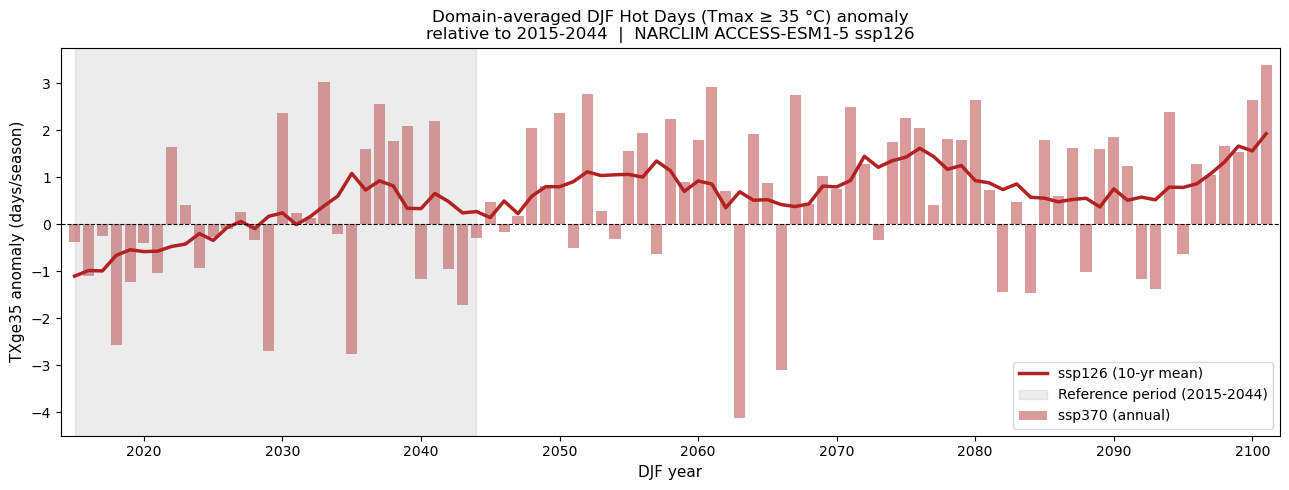

In [2]:
# ================================================================
# Anomaly time series (domain-averaged; robust to changing NaNs)
# ================================================================

# Freeze the spatial domain to cells valid in the REFERENCE climatology
fixed_cells = np.isfinite(seas_ref)  # True only where reference climatology is valid

# Apply fixed mask to all years BEFORE spatial averaging
seas_annual_fixed = seas_annual.where(fixed_cells)

# Spatial dims (works whether dims are rlat/rlon or y/x etc.)
spatial_dims = [d for d in seas_annual_fixed.dims if d != "season_year"]

# Domain mean per year (skipna over the fixed domain)
seas_ts = seas_annual_fixed.mean(dim=spatial_dims, skipna=True)

# ---- Diagnostics to avoid spurious late-century dips ----
# Count of valid cells each year within the fixed domain
valid_count = seas_annual_fixed.notnull().sum(dim=spatial_dims)

# Total number of fixed cells (True cells) — THIS IS THE KEY FIX
fixed_count = fixed_cells.sum(dim=spatial_dims)

# Fraction of fixed cells that remain valid each year
valid_frac = valid_count / fixed_count

print("Fixed domain cell count:", int(fixed_count.values))
print("Valid fraction range:", float(valid_frac.min().values), "to", float(valid_frac.max().values))

# Optional: drop years with too much missingness
MIN_VALID_FRAC = 0.90  # start relaxed; tighten later if you want
seas_ts = seas_ts.where(valid_frac >= MIN_VALID_FRAC)

# Reference mean (near-term)
ref_mean = float(seas_ts.sel(season_year=slice(REF_START, REF_END)).mean(skipna=True).values)

# Anomaly relative to reference mean
seas_anom = seas_ts - ref_mean
years = seas_anom["season_year"].values
anom = seas_anom.values

print(f"Index : {INDEX}  ({INDEX_LABEL.get(INDEX, INDEX)})")
print(f"Reference mean ({REF_START}-{REF_END}): {ref_mean:.2f} days/season")
print(f"Year range: {int(np.nanmin(years))} - {int(np.nanmax(years))}  ({len(years)} years)")
print(f"Masked years dropped (valid fraction < {MIN_VALID_FRAC:.2f}): {int(np.sum(~np.isfinite(anom)))}")


def running_mean_nan(x, n=10):
    """NaN-aware running mean (centered)."""
    x = np.asarray(x, dtype=float)
    w = np.ones(n, dtype=float)
    valid = np.isfinite(x).astype(float)
    x0 = np.where(np.isfinite(x), x, 0.0)
    num = np.convolve(x0, w, mode="same")
    den = np.convolve(valid, w, mode="same")
    return num / np.where(den == 0, np.nan, den)


# Figure size 1300x500 => 13x5 inches at ~100 dpi
fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(years, anom, color="firebrick", alpha=0.45, label="ssp370 (annual)")
ax.plot(years, running_mean_nan(anom, n=10), color="firebrick", lw=2.5,
        label="ssp126 (10-yr mean)")

ax.axvspan(REF_START, REF_END, color="grey", alpha=0.15,
           label=f"Reference period ({REF_START}-{REF_END})")
ax.axhline(0, color="black", lw=0.8, ls="--")

ax.set_xlim(int(np.nanmin(years)) - 1, int(np.nanmax(years)) + 1)
ax.set_xlabel(f"{SEASON} year", fontsize=11)
ax.set_ylabel(f"{INDEX} anomaly (days/season)", fontsize=11)
ax.set_title(
    f"Domain-averaged {SEASON} {INDEX_LABEL.get(INDEX, INDEX)} anomaly\n"
    f"relative to {REF_START}-{REF_END}  |  NARCLIM ACCESS-ESM1-5 ssp126",
    fontsize=12
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()